<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/NASSCOM_Day_3_P%26S_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.501  (true 0.5)
P(>4)   ~ 0.333  (true 0.333)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.33
P(1 or 2)   = 0.33  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# -----------------------------------------------------------
# 🔹 1C. COMPOUND EVENTS (P(A and B))
# -----------------------------------------------------------


In [6]:
#P(both heads)  -> heads == 2

flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2
p_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(p_both_heads, 3), ' (true 0.25)')

P(both heads) ~ 0.251  (true 0.25)


In [8]:
#P(at least one head)  -> heads >= 1

p_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) ~', round(p_at_least_one_head, 3), ' (true 0.75)')

P(at least one head) ~ 0.751  (true 0.75)


In [9]:
p_0_heads = (heads == 0).mean()
print('P(0 heads) ~', round(p_0_heads, 3), ' (true 0.25)')

P(0 heads) ~ 0.249  (true 0.25)


In [10]:
p_1_head = (heads == 1).mean()
print('P(1 head) ~', round(p_1_head, 3), ' (true 0.5)')

P(1 head) ~ 0.5  (true 0.5)


### Do P(0) + P(1) + P(2) sum to 1?

In [11]:
#Do P(0) + P(1) + P(2) sum to 1?

total_probability = p_0_heads + p_1_head + p_both_heads
print('P(0) + P(1) + P(2) =', round(total_probability, 3))

P(0) + P(1) + P(2) = 1.0


In [12]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.336  (true 1/3)


In [13]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.499
P(A | B)  = 0.668
Independent? False


In [14]:
rolls = np.random.randint(1, 7, size=100_000)

In [15]:
# P(odd | roll < 4): narrow the world to rolls < 4
rolls_less_than_4 = rolls[rolls < 4] # condition on 'rolls < 4'
p_odd_given_less_than_4 = (rolls_less_than_4 % 2 != 0).mean()
print('P(odd | roll < 4) ~', round(p_odd_given_less_than_4, 3), ' (true 0.667)')

P(odd | roll < 4) ~ 0.667  (true 0.667)


In [17]:
#Compare P(odd | <4) with P(odd) overall — independent?

p_odd_overall = (rolls % 2 != 0).mean()
print(f'P(odd) overall ~ {round(p_odd_overall, 3)} (true 0.5)')

print('P(odd | roll < 4) =', round(p_odd_given_less_than_4, 3))
print('P(odd) overall    =', round(p_odd_overall, 3))
print('Independent?', np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.02))

P(odd) overall ~ 0.501 (true 0.5)
P(odd | roll < 4) = 0.667
P(odd) overall    = 0.501
Independent? False


In [18]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [19]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.5


In [20]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

In [22]:
# P('free') via total probability
p_ham = 1 - p_spam
p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham
print('P(free) =', round(p_free, 3))

P(free) = 0.16


In [23]:
# Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free') =", round(p_spam_given_free, 3))

P(spam | 'free') = 0.75


In [26]:
import scipy.stats as stats

# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.3 (true 0.3)
Poisson(4) mean ~ 3.974 (true 4)


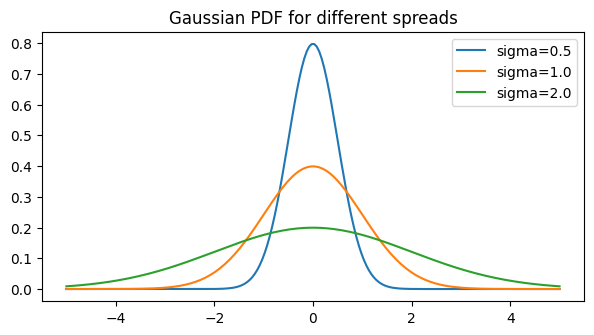

In [28]:
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

## Resources
Poisson(mu=2) samples + mean

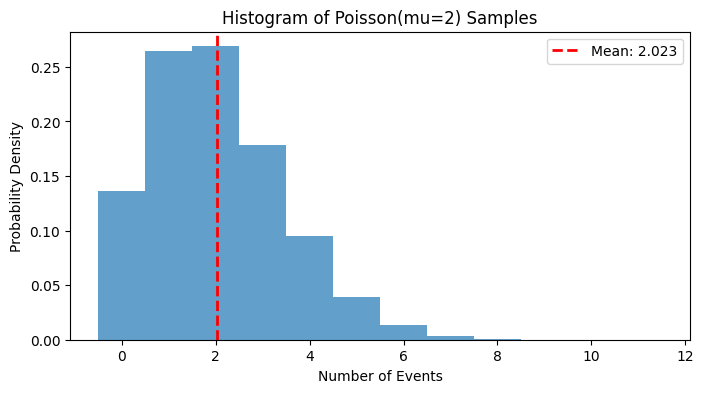

Poisson(mu=2) sample mean: 2.023 (true 2)


In [29]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate Poisson samples with mu=2
poisson_samples = stats.poisson(mu=2).rvs(size=10_000)

# Calculate the mean of the samples
poisson_mean = poisson_samples.mean()

# Plot the histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(poisson_samples, bins=range(int(poisson_samples.max()) + 2), align='left', density=True, alpha=0.7)

# Add a vertical line for the mean
ax.axvline(poisson_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {poisson_mean:.3f}')

ax.set_title('Histogram of Poisson(mu=2) Samples')
ax.set_xlabel('Number of Events')
ax.set_ylabel('Probability Density')
ax.legend()
plt.show()

print(f'Poisson(mu=2) sample mean: {poisson_mean:.3f} (true 2)')

### Histogram of Poisson Samples

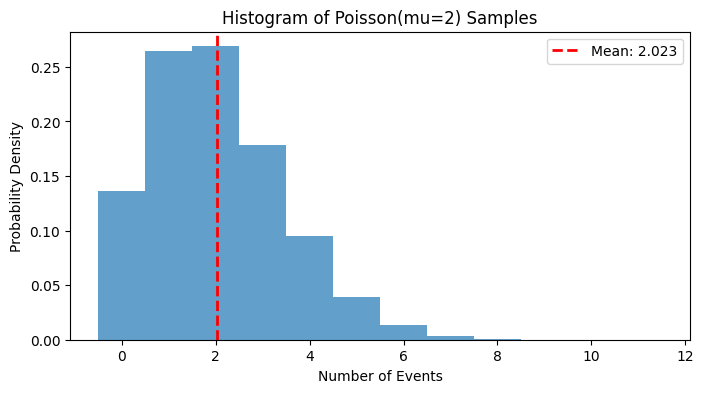

In [30]:
import matplotlib.pyplot as plt

# Assuming 'poisson_samples' is still available from the previous execution
# If not, you would need to regenerate them:
# import scipy.stats as stats
# poisson_samples = stats.poisson(mu=2).rvs(size=10_000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(poisson_samples, bins=range(int(poisson_samples.max()) + 2), align='left', density=True, alpha=0.7)

# Add a vertical line for the mean (if 'poisson_mean' is available)
if 'poisson_mean' in locals() or 'poisson_mean' in globals():
    ax.axvline(poisson_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {poisson_mean:.3f}')

ax.set_title('Histogram of Poisson(mu=2) Samples')
ax.set_xlabel('Number of Events')
ax.set_ylabel('Probability Density')
ax.legend()
plt.show()

### Gaussian PDF for Two Sigmas

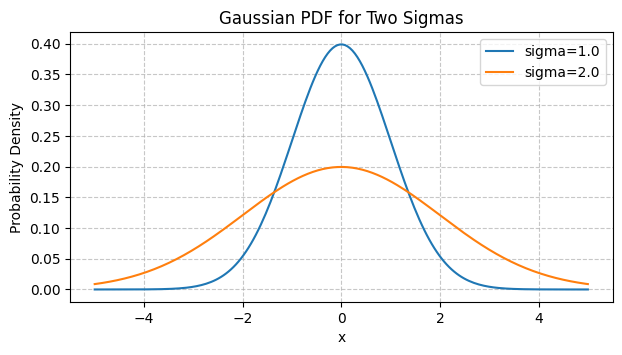

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))

# Plot for sigma = 1.0
ax.plot(x, stats.norm(0, 1.0).pdf(x), label='sigma=1.0')

# Plot for sigma = 2.0
ax.plot(x, stats.norm(0, 2.0).pdf(x), label='sigma=2.0')

ax.set_title('Gaussian PDF for Two Sigmas')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [32]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [33]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [34]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


### Entropy of Fair Dice

In [35]:
from scipy.stats import entropy

# Probability distribution for a fair 4-sided die
# Each side has a probability of 1/4
fair_4_sided = [1/4, 1/4, 1/4, 1/4]

# Probability distribution for a fair 6-sided die
# Each side has a probability of 1/6
fair_6_sided = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

# Calculate entropy for the 4-sided die (base=2 for bits)
entropy_4_sided = entropy(fair_4_sided, base=2)

# Calculate entropy for the 6-sided die (base=2 for bits)
entropy_6_sided = entropy(fair_6_sided, base=2)

print(f'Entropy of a fair 4-sided die: {entropy_4_sided:.3f} bits')
print(f'Entropy of a fair 6-sided die: {entropy_6_sided:.3f} bits')
print('-> As expected, the 6-sided die has higher entropy because it has more possible outcomes, meaning more uncertainty.')

Entropy of a fair 4-sided die: 2.000 bits
Entropy of a fair 6-sided die: 2.585 bits
-> As expected, the 6-sided die has higher entropy because it has more possible outcomes, meaning more uncertainty.


### KL Divergence with new distributions

In [36]:
P_new = np.array([0.7, 0.3])
Q_new = np.array([0.5, 0.5])

print('New P:', P_new)
print('New Q:', Q_new)

# Calculate KL divergence D(P || Q)
kld_P_Q = entropy(P_new, Q_new, base=2)
print(f'D(P || Q) = {kld_P_Q:.3f} bits')

# Calculate KL divergence D(Q || P)
kld_Q_P = entropy(Q_new, P_new, base=2)
print(f'D(Q || P) = {kld_Q_P:.3f} bits')

# Calculate KL divergence D(P || P) for sanity check
kld_P_P = entropy(P_new, P_new, base=2)
print(f'D(P || P) = {kld_P_P:.3f} bits (should be zero)')

print('-> Notice again that D(P||Q) != D(Q||P), confirming it is not symmetric.')

New P: [0.7 0.3]
New Q: [0.5 0.5]
D(P || Q) = 0.119 bits
D(Q || P) = 0.126 bits
D(P || P) = 0.000 bits (should be zero)
-> Notice again that D(P||Q) != D(Q||P), confirming it is not symmetric.


From the mutual information calculation, the most informative iris feature is petal length (cm) with a score of 0.990, and the least informative is sepal width (cm) with a score of 0.286.